#Import necessary libraries
#Perform initial data exploration and analyze missing values

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from zlib import crc32
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator
from sklearn.base import TransformerMixin
from sklearn.utils.validation import check_array ,check_is_fitted
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv")

In [36]:
print(df.info())
print(df.corr(numeric_only=True))
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values Count:")
print(df.isnull().sum())
print("\nNumber of Unique Values per Column:")
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclas


> Add blockquote



<Axes: xlabel='Parch', ylabel='Count'>

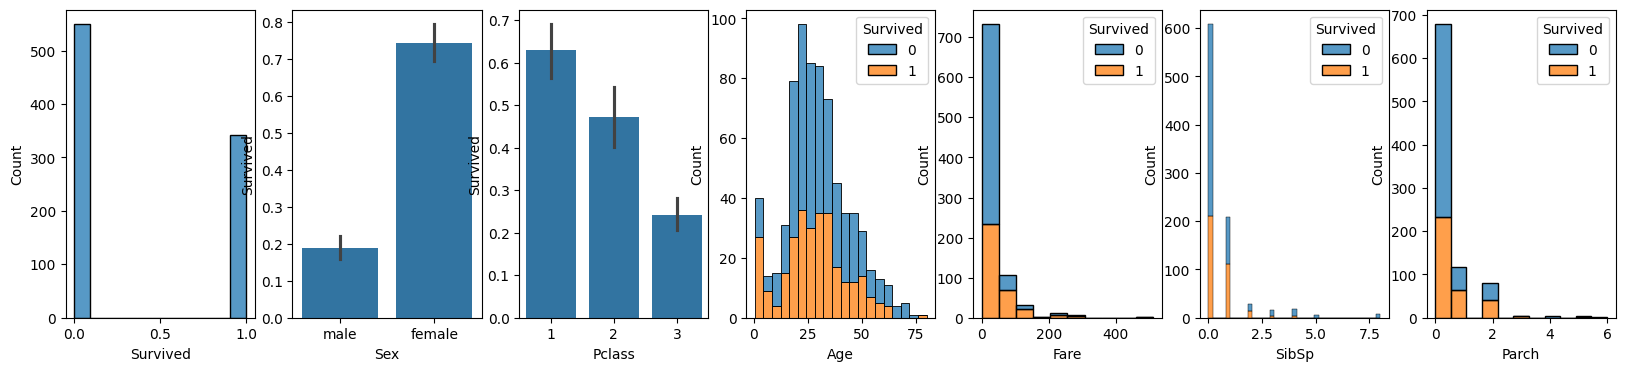

In [37]:
fig, axes = plt.subplots(1, 7, figsize=(20, 4))
sns.histplot(data = df , x = "Survived" , ax = axes[0])
sns.barplot(data = df , x = "Sex",y="Survived", ax = axes[1])
sns.barplot(data=df,x="Pclass",y="Survived",ax = axes[2])
sns.histplot(data=df, x="Age", hue="Survived",multiple="stack", ax =axes[3])
sns.histplot(data=df, x="Fare", hue="Survived",multiple="stack", ax =axes[4],bins = 10)
sns.histplot(data=df, x="SibSp", hue="Survived",multiple="stack", ax =axes[5])
sns.histplot(data=df, x="Parch", hue="Survived", multiple="stack",ax =axes[6])

# Handle missing values using appropriate imputation strategies

In [38]:
si = SimpleImputer(strategy="median")
df["Age"] = si.fit_transform(df[["Age"]])
df = df.drop(columns =["Cabin"])
si = SimpleImputer(strategy="most_frequent")
df["Embarked"] = pd.DataFrame(si.fit_transform(df[["Embarked"]]),columns=["Embarked"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


# Implement feature engineering by creating FamilySize, extracting and grouping Title values, and dropping irrelevant features


In [39]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print(df.info())
df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
print(df["Title"].value_counts())
title_mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
}
df["Title"] = df["Title"].replace(title_mapping)
main_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"][~df["Title"].isin(main_titles)] = "Rare"
print(df["Title"].value_counts(),"\n",df.info())
df.drop(columns=["PassengerId","Name","Ticket","SibSp","Parch"],inplace = True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB
None
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt     

<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1755/3212595063.py:3: SyntaxWarning: invalid escape sequence '\.'
  df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/tmp/ipykernel_1755/3212595063.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://p

# Encode categorical features into numerical representations

In [40]:
print(df.info(),df["Sex"].value_counts(), df["Embarked"].value_counts(), df["Title"].value_counts())
####
oe = OrdinalEncoder()
df["Sex"] = oe.fit_transform(df[["Sex"]])
####
ohe = OneHotEncoder()
CategoricalTransformed = ohe.fit_transform(df[["Embarked","Title"]])
CategoricalTransformed = CategoricalTransformed.toarray()
CategoricalTransformed = pd.DataFrame(CategoricalTransformed,columns = ohe.get_feature_names_out())
print(CategoricalTransformed, df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   Fare        891 non-null    float64
 5   Embarked    891 non-null    object 
 6   FamilySize  891 non-null    int64  
 7   Title       891 non-null    object 
dtypes: float64(2), int64(3), object(3)
memory usage: 55.8+ KB
None Sex
male      577
female    314
Name: count, dtype: int64 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64 Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survi